# 03 - Fine-Tuning with LoRA
Parameter-efficient fine-tuning of ESM-2 using LoRA for pathogen virulence gene functional class classification.

## GoHREP

**Goal:**

Fine-tune ESM-2 using LoRA (Low-Rank Adaptation) to classify pathogen virulence gene sequences from PHI-base into 8 functional classes, improving on the 75.2% accuracy and 0.711 macro F1 established by the frozen embedding baseline in notebook 02.

**Hypothesis:**

LoRA fine-tuning of ESM-2's attention and feed-forward layers will adapt the encoder's pre-trained representations to better capture functional class-specific sequence signatures, meaningfully improving classification performance over the frozen baseline - particularly for the weaker classes (Secondary metabolite / Biosynthesis F1: 0.618, Protease F1: 0.611) where frozen embeddings struggle to separate biochemically overlapping sequences.

**Rationale:**

The frozen embedding baseline (75.2% accuracy, 0.711 macro F1) demonstrated that ESM-2's pre-trained representations already encode substantial functional class signal. However, ESM-2 was pre-trained on evolutionary sequence data without any exposure to pathogen-specific functional annotations, meaning its representations are not optimally organised for this classification task. LoRA fine-tuning adapts the encoder's attention mechanisms and feed-forward layers to better separate the 8 functional classes while retaining the general biochemical knowledge encoded during pre-training. Critically, LoRA achieves this with only 0.1-1% of the full parameter count, making fine-tuning feasible on Colab A100 hardware. Class-weighted loss is retained from the baseline to ensure the smaller classes (Protease, Secretion system) receive sufficient training signal relative to the larger classes (Transcription factor / Regulator, Kinase / Signalling).

**Experimental Plan:**

1. **Data loading:** Load saved train/val/test splits from `data/splits/fine_tuning_dataset/` and convert to HuggingFace `Dataset` format for efficient batching.
2. **Model architecture:** Load base ESM-2, apply LoRA adapters to attention and feed-forward layers, and attach the 8-class classification head (640 → 256 → 128 → 8) consistent with the prototyping architecture.
3. **Training configuration:** Configure training arguments with batch size informed by memory profiling in notebook 02, cosine learning rate schedule with warmup, mixed precision (fp16), and early stopping.
4. **Weights & Biases integration:** Initialise W&B tracking with frozen baseline metrics as reference, logging per-class F1 scores and confusion matrices throughout training.
5. **Training execution:** Fine-tune with the HuggingFace Trainer and monitor convergence against the frozen baseline.
6. **Error analysis:** Evaluate on the validation set with per-class F1 scores, confusion matrix, top-2 prediction analysis, and truncation analysis of fine-tuned embeddings compared against frozen baseline embeddings.
7. **Model saving:** Save LoRA adapters, classification head weights, and deployment config to Drive and push to GitHub.

# 0 Environment Setup

This section mounts Google Drive and installs dependencies from the GitHub repository.

In [8]:
import yaml
from google.colab import drive
import os

drive.mount('/content/drive')
PROJECT_ROOT = "/content/drive/MyDrive/esm-phi-effector"
os.chdir(PROJECT_ROOT)

# Load config files
model_config_path    = os.path.join(PROJECT_ROOT, "configs/model_config.yaml")
training_config_path = os.path.join(PROJECT_ROOT, "configs/training_config.yaml")

with open(model_config_path, 'r') as f:
    model_config = yaml.safe_load(f)

with open(training_config_path, 'r') as f:
    training_config = yaml.safe_load(f)

print("Configs loaded:")
print(f"  Model:    {model_config['model']['base_model']}")
print(f"  Classes:  {model_config['model']['num_classes']}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Configs loaded:
  Model:    facebook/esm2_t30_150M_UR50D
  Classes:  8


In [2]:
if os.path.exists("requirements.txt"):
    !pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.0/258.0 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 134.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.3/145.3 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 720.1/72

In [3]:
# Imports
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModel,
    TrainingArguments, Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType
import wandb

print(f"PyTorch version:  {torch.__version__}")
print(f"CUDA available:   {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:              {torch.cuda.get_device_name(0)}")

PyTorch version:  2.10.0+cu128
CUDA available:   True
GPU:              NVIDIA A100-SXM4-40GB


## 1 Data Loading

This section loads the curated train/val/test splits saved during data curation, verifies label integrity, and converts to HuggingFace Dataset format for use with the Trainer API.


The key difference from notebook 02 is the tokenization step here produces padded tensors stored in a HuggingFace Dataset rather than raw sequences passed to the embedding extraction loop, since the Trainer handles batching and forward passes internally.

In [4]:
# Load saved splits from data curation
splits_dir = os.path.join(PROJECT_ROOT, model_config['paths']['splits_dir'], "fine_tuning_dataset")

train_data = torch.load(os.path.join(splits_dir, "train.pt"))
val_data   = torch.load(os.path.join(splits_dir, "val.pt"))
test_data  = torch.load(os.path.join(splits_dir, "test.pt"))

print(f"Train: {len(train_data['sequences'])} sequences")
print(f"Val:   {len(val_data['sequences'])} sequences")
print(f"Test:  {len(test_data['sequences'])} sequences")

# Verify label mapping is consistent across splits
print(f"\nLabel mapping: {train_data['label_mapping']}")
assert train_data['label_mapping'] == val_data['label_mapping'] == test_data['label_mapping'], \
    "Label mapping mismatch between splits!"
print("Label mapping consistent across splits: OK")

Train: 3614 sequences
Val:   452 sequences
Test:  452 sequences

Label mapping: {'Effector': 0, 'Transcription factor / Regulator': 1, 'Kinase / Signalling': 2, 'Protease': 3, 'Cell wall / Carbohydrate-active': 4, 'Transporter / Membrane': 5, 'Secondary metabolite / Biosynthesis': 6, 'Secretion system': 7}
Label mapping consistent across splits: OK


In [5]:
# Tokenize sequences and convert to HuggingFace Dataset format
model_name = train_data['model']
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_build_dataset(data, tokenizer, max_length=1024):
    tokenized = tokenizer(
        data['sequences'],
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )
    return Dataset.from_dict({
        'input_ids':      tokenized['input_ids'],
        'attention_mask': tokenized['attention_mask'],
        'labels':         data['labels']
    })

print("Tokenizing splits...")
train_dataset = tokenize_and_build_dataset(train_data, tokenizer)
val_dataset   = tokenize_and_build_dataset(val_data,   tokenizer)
test_dataset  = tokenize_and_build_dataset(test_data,  tokenizer)

print(f"\nDatasets ready:")
print(f"  Train: {len(train_dataset)} sequences")
print(f"  Val:   {len(val_dataset)} sequences")
print(f"  Test:  {len(test_dataset)} sequences")

# Verify class distributions
from collections import Counter
idx_to_class = {v: k for k, v in train_data['label_mapping'].items()}

for split_name, split_data in [("Train", train_data), ("Val", val_data), ("Test", test_data)]:
    counts = Counter(split_data['labels'])
    print(f"\n{split_name} class distribution:")
    for cls, idx in sorted(train_data['label_mapping'].items(), key=lambda x: x[1]):
        print(f"  {cls:<45} {counts[idx]:>5}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Tokenizing splits...

Datasets ready:
  Train: 3614 sequences
  Val:   452 sequences
  Test:  452 sequences

Train class distribution:
  Effector                                        526
  Transcription factor / Regulator               1251
  Kinase / Signalling                             805
  Protease                                        157
  Cell wall / Carbohydrate-active                 221
  Transporter / Membrane                          296
  Secondary metabolite / Biosynthesis             198
  Secretion system                                160

Val class distribution:
  Effector                                         66
  Transcription factor / Regulator                156
  Kinase / Signalling                             101
  Protease                                         20
  Cell wall / Carbohydrate-active                  27
  Transporter / Membrane                           37
  Secondary metabolite / Biosynthesis              25
  Secretion system            

## 2 Model Architecture with LoRA Integration

This section loads the base ESM-2 encoder, applies LoRA adapters to the attention and feed-forward layers, and attaches the 8-class classification head. The architecture is consistent with the prototyping notebook - masked mean pooling over the sequence length followed by progressive dimension reduction (640 → 256 → 128 → 8) - with the key difference that the ESM-2 encoder is now partially trainable via LoRA rather than fully frozen.

In [9]:
# Load base ESM-2 model
model_name = train_data['model']
base_model = AutoModel.from_pretrained(model_name)

# Configure LoRA
lora_config = LoraConfig(
    r=training_config['lora']['rank'],
    lora_alpha=training_config['lora']['alpha'],
    target_modules=training_config['lora']['target_modules'],
    lora_dropout=training_config['lora']['dropout'],
    bias=training_config['lora']['bias'],
    task_type=TaskType.FEATURE_EXTRACTION
)

# Wrap ESM-2 with LoRA adapters
lora_esm = get_peft_model(base_model, lora_config)
lora_esm.print_trainable_parameters()

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 5,550,080 || all params: 153,688,921 || trainable%: 3.6112


In [10]:
# Compute class weights from training labels
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(model_config['model']['num_classes']),
    y=train_data['labels']
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to("cuda")

print("Class weights:")
for cls, w in zip(train_data['label_mapping'].keys(), class_weights):
    print(f"  {cls:<45} {w:.3f}")

Class weights:
  Effector                                      0.859
  Transcription factor / Regulator              0.361
  Kinase / Signalling                           0.561
  Protease                                      2.877
  Cell wall / Carbohydrate-active               2.044
  Transporter / Membrane                        1.526
  Secondary metabolite / Biosynthesis           2.282
  Secretion system                              2.823


In [11]:
class ESM2ForVirulenceClassification(nn.Module):
    def __init__(self, esm_model, num_classes=8, hidden_dim=640,
                 layer_1_dim=256, layer_2_dim=128,
                 dropout_rate=0.1, class_weights=None):
        super().__init__()
        self.esm = esm_model
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, layer_1_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(layer_1_dim, layer_2_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(layer_2_dim, num_classes)
        )
        self.class_weights = class_weights

    def forward(self, input_ids, attention_mask=None, labels=None):
        # Get ESM-2 embeddings
        outputs = self.esm(input_ids=input_ids, attention_mask=attention_mask)
        embeddings = outputs.last_hidden_state  # (batch_size, seq_len, hidden_dim)

        # Masked mean pooling - exclude padding tokens
        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1).float()
            sum_embeddings = (embeddings * mask).sum(dim=1)
            lengths = mask.sum(dim=1)
            pooled = sum_embeddings / lengths
        else:
            pooled = embeddings.mean(dim=1)

        # Classification head
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)

        # Class-weighted loss
        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
            loss = loss_fn(logits, labels)

        return {'loss': loss, 'logits': logits}


# Instantiate model
model = ESM2ForVirulenceClassification(
    esm_model=lora_esm,
    num_classes=model_config['model']['num_classes'],
    hidden_dim=model_config['model']['hidden_dim'],
    layer_1_dim=model_config['classification_head']['layer_1_dim'],
    layer_2_dim=model_config['classification_head']['layer_2_dim'],
    dropout_rate=model_config['model']['dropout_rate'],
    class_weights=class_weights_tensor
)

model = model.to("cuda")

# Parameter summary
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in model.parameters())
frozen_params    = total_params - trainable_params

print(f"\nParameter summary:")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable (LoRA + head): {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")
print(f"  Frozen (ESM-2 base):  {frozen_params:,} ({frozen_params/total_params*100:.2f}%)")


Parameter summary:
  Total parameters:     153,886,945
  Trainable (LoRA + head): 5,748,104 (3.74%)
  Frozen (ESM-2 base):  148,138,841 (96.26%)


## 3 Weights & Biases Integration

This section initialises Weights & Biases tracking for the fine-tuning run. W&B logs training loss, validation metrics, and per-class F1 scores throughout training, enabling real-time monitoring and comparison across hyperparameter configurations. The frozen baseline metrics from notebook 02 are logged as reference points.

In [12]:
# Authenticate W&B using Colab Secrets
import wandb
from google.colab import userdata

wandb.login(key=userdata.get('WANDB_API_KEY'))

# Initialise run
run = wandb.init(
    project=training_config['logging']['project_name'],
    name=f"lora_r{training_config['lora']['rank']}_lr{training_config['training']['learning_rate']}",
    config={
        # Model
        "base_model":     model_name,
        "num_classes":    model_config['model']['num_classes'],
        "hidden_dim":     model_config['model']['hidden_dim'],
        "layer_1_dim":    model_config['classification_head']['layer_1_dim'],
        "layer_2_dim":    model_config['classification_head']['layer_2_dim'],
        "dropout_rate":   model_config['model']['dropout_rate'],
        # LoRA
        "lora_rank":          training_config['lora']['rank'],
        "lora_alpha":         training_config['lora']['alpha'],
        "lora_dropout":       training_config['lora']['dropout'],
        "lora_target_modules": training_config['lora']['target_modules'],
        # Training
        "learning_rate":              training_config['training']['learning_rate'],
        "num_epochs":                 training_config['training']['num_epochs'],
        "batch_size":                 training_config['training']['per_device_train_batch_size'],
        "gradient_accumulation_steps": training_config['training']['gradient_accumulation_steps'],
        "weight_decay":               training_config['training']['weight_decay'],
        "warmup_ratio":               training_config['training']['warmup_ratio'],
        "lr_scheduler_type":          training_config['training']['lr_scheduler_type'],
        "class_weighting":            True,
        # Dataset
        "train_size": len(train_dataset),
        "val_size":   len(val_dataset),
        "test_size":  len(test_dataset),
    }
)

# Log frozen baseline metrics as reference
wandb.log({
    "baseline/accuracy":        0.752,
    "baseline/macro_f1":        0.711,
    "baseline/weighted_f1":     0.757,
    "baseline/f1_effector":                         0.778,
    "baseline/f1_transcription_factor_regulator":   0.827,
    "baseline/f1_kinase_signalling":                0.745,
    "baseline/f1_protease":                         0.611,
    "baseline/f1_cell_wall_carbohydrate_active":    0.786,
    "baseline/f1_transporter_membrane":             0.667,
    "baseline/f1_secondary_metabolite_biosynthesis": 0.618,
    "baseline/f1_secretion_system":                 0.654,
})

print(f"W&B run initialised: {run.name}")
print(f"Track at: {run.url}")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: joshuandwilliams (agseer) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B run initialised: lora_r16_lr0.0002
Track at: https://wandb.ai/agseer/esm-phi-effector/runs/zpklefcd


## 4 Training Execution

This section defines the evaluation metrics, configures the HuggingFace Trainer, and executes LoRA fine-tuning. Training is monitored via Weights & Biases and early stopping is applied based on macro F1 score on the validation set.

In [13]:
# Define evaluation metrics
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average=None,
        labels=list(range(model_config['model']['num_classes']))
    )
    f1_macro    = np.mean(f1)
    f1_weighted = precision_recall_fscore_support(
        labels, predictions, average='weighted'
    )[2]

    # Per-class metrics for W&B logging
    metrics = {
        'accuracy':    accuracy,
        'f1_macro':    f1_macro,
        'f1_weighted': f1_weighted,
    }
    for cls, idx in train_data['label_mapping'].items():
        safe_key = cls.lower().replace(' ', '_').replace('/', '_')
        metrics[f'f1_{safe_key}']        = f1[idx]
        metrics[f'precision_{safe_key}'] = precision[idx]
        metrics[f'recall_{safe_key}']    = recall[idx]

    return metrics

In [14]:
# Configure TrainingArguments
output_dir = os.path.join(PROJECT_ROOT, training_config['paths']['output_dir'])
os.makedirs(output_dir, exist_ok=True)

training_args = TrainingArguments(
    output_dir=output_dir,

    # Training schedule
    num_train_epochs=training_config['training']['num_epochs'],
    per_device_train_batch_size=training_config['training']['per_device_train_batch_size'],
    per_device_eval_batch_size=training_config['training']['per_device_eval_batch_size'],
    gradient_accumulation_steps=training_config['training']['gradient_accumulation_steps'],

    # Optimisation
    learning_rate=training_config['training']['learning_rate'],
    weight_decay=training_config['training']['weight_decay'],
    warmup_ratio=training_config['training']['warmup_ratio'],
    lr_scheduler_type=training_config['training']['lr_scheduler_type'],

    # Evaluation and saving
    eval_strategy=training_config['evaluation']['strategy'],
    save_strategy=training_config['evaluation']['save_strategy'],
    save_total_limit=training_config['evaluation']['save_total_limit'],
    load_best_model_at_end=training_config['evaluation']['load_best_model_at_end'],
    metric_for_best_model=training_config['evaluation']['metric_for_best_model'],
    greater_is_better=training_config['evaluation']['greater_is_better'],

    # Mixed precision and efficiency
    fp16=training_config['training']['fp16'],
    dataloader_num_workers=2,
    remove_unused_columns=False,

    # Logging
    logging_steps=training_config['logging']['steps'],
    report_to=training_config['logging']['report_to'],
    run_name=run.name,
)

# Early stopping callback
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=training_config['training']['early_stopping_patience'],
    early_stopping_threshold=training_config['training']['early_stopping_threshold']
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [16]:
# Initialise Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

# Print summary before training
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in model.parameters())

print("Training summary:")
print(f"  Base model:              {model_name}")
print(f"  LoRA rank:               {training_config['lora']['rank']}")
print(f"  Trainable parameters:    {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")
print(f"  Train sequences:         {len(train_dataset)}")
print(f"  Val sequences:           {len(val_dataset)}")
print(f"  Effective batch size:    {training_config['training']['per_device_train_batch_size'] * training_config['training']['gradient_accumulation_steps']}")
print(f"  Max epochs:              {training_config['training']['num_epochs']}")
print(f"  Early stopping patience: {training_config['training']['early_stopping_patience']}")
print(f"\nFrozen baseline to beat:")
print(f"  Accuracy:  75.2%")
print(f"  Macro F1:  0.711")
print(f"\nStarting training...")

Training summary:
  Base model:              facebook/esm2_t30_150M_UR50D
  LoRA rank:               16
  Trainable parameters:    5,748,104 (3.74%)
  Train sequences:         3614
  Val sequences:           452
  Effective batch size:    16
  Max epochs:              20
  Early stopping patience: 3

Frozen baseline to beat:
  Accuracy:  75.2%
  Macro F1:  0.711

Starting training...


In [17]:
# Execute fine-tuning
train_result = trainer.train()

print("\nTraining complete!")
print(f"  Total steps:      {train_result.global_step}")
print(f"  Training loss:    {train_result.training_loss:.4f}")
print(f"  Training time:    {train_result.metrics['train_runtime']:.1f}s ({train_result.metrics['train_runtime']/60:.1f} min)")

# Final validation evaluation
val_results = trainer.evaluate(val_dataset)
print(f"\nFinal validation results:")
print(f"  Accuracy:    {val_results['eval_accuracy']*100:.1f}%")
print(f"  Macro F1:    {val_results['eval_f1_macro']:.3f}")
print(f"  Weighted F1: {val_results['eval_f1_weighted']:.3f}")
print(f"\nVs frozen baseline:")
print(f"  Accuracy:  75.2% → {val_results['eval_accuracy']*100:.1f}%  ({val_results['eval_accuracy']*100 - 75.2:+.1f}%)")
print(f"  Macro F1:  0.711 → {val_results['eval_f1_macro']:.3f}  ({val_results['eval_f1_macro'] - 0.711:+.3f})")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Effector,Precision Effector,Recall Effector,F1 Transcription Factor Regulator,Precision Transcription Factor Regulator,Recall Transcription Factor Regulator,F1 Kinase Signalling,Precision Kinase Signalling,Recall Kinase Signalling,F1 Protease,Precision Protease,Recall Protease,F1 Cell Wall Carbohydrate-active,Precision Cell Wall Carbohydrate-active,Recall Cell Wall Carbohydrate-active,F1 Transporter Membrane,Precision Transporter Membrane,Recall Transporter Membrane,F1 Secondary Metabolite Biosynthesis,Precision Secondary Metabolite Biosynthesis,Recall Secondary Metabolite Biosynthesis,F1 Secretion System,Precision Secretion System,Recall Secretion System
1,1.963990,1.756304,0.511062,0.292229,0.441743,0.738255,0.662651,0.833333,0.708543,0.582645,0.903846,0.171429,0.202703,0.148515,0.000000,0.000000,0.000000,0.352941,0.375000,0.333333,0.366667,0.478261,0.297297,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1.211518,1.096710,0.699115,0.592653,0.703772,0.822581,0.879310,0.772727,0.829091,0.957983,0.730769,0.677249,0.727273,0.633663,0.000000,0.000000,0.000000,0.597015,0.500000,0.740741,0.658824,0.583333,0.756757,0.489796,0.328767,0.960000,0.666667,0.600000,0.750000
3,0.805130,0.980483,0.785398,0.742125,0.786570,0.826446,0.909091,0.757576,0.839344,0.859060,0.820513,0.783019,0.747748,0.821782,0.625000,0.833333,0.500000,0.800000,0.785714,0.814815,0.717949,0.682927,0.756757,0.678571,0.612903,0.760000,0.666667,0.600000,0.750000
4,0.647577,0.927207,0.789823,0.741124,0.794683,0.784000,0.830508,0.742424,0.874126,0.961538,0.801282,0.798077,0.775701,0.821782,0.628571,0.733333,0.550000,0.777778,0.777778,0.777778,0.709677,0.589286,0.891892,0.703704,0.655172,0.760000,0.653061,0.551724,0.800000
5,0.489851,0.984366,0.800885,0.756236,0.804223,0.830769,0.843750,0.818182,0.868687,0.914894,0.826923,0.798030,0.794118,0.801980,0.702703,0.764706,0.650000,0.777778,0.777778,0.777778,0.759494,0.714286,0.810811,0.631579,0.562500,0.720000,0.680851,0.592593,0.800000
6,0.369248,1.158455,0.778761,0.728951,0.783003,0.787879,0.787879,0.787879,0.867797,0.920863,0.820513,0.769231,0.797872,0.742574,0.666667,0.846154,0.550000,0.800000,0.869565,0.740741,0.686275,0.538462,0.945946,0.689655,0.606061,0.800000,0.564103,0.578947,0.550000
7,0.271495,1.269751,0.800885,0.760528,0.801607,0.805970,0.794118,0.818182,0.863787,0.896552,0.833333,0.794393,0.752212,0.841584,0.705882,0.857143,0.600000,0.816327,0.909091,0.740741,0.746988,0.673913,0.837838,0.666667,0.653846,0.680000,0.684211,0.722222,0.650000
8,0.224679,1.260774,0.787611,0.747126,0.790202,0.800000,0.847458,0.757576,0.853333,0.888889,0.820513,0.784314,0.776699,0.792079,0.742857,0.866667,0.650000,0.769231,0.800000,0.740741,0.727273,0.627451,0.864865,0.700000,0.600000,0.840000,0.600000,0.600000,0.600000
9,0.106395,1.507092,0.785398,0.744302,0.787471,0.812030,0.805970,0.818182,0.851351,0.900000,0.807692,0.773585,0.738739,0.811881,0.685714,0.800000,0.600000,0.775510,0.863636,0.703704,0.722892,0.652174,0.810811,0.666667,0.593750,0.760000,0.666667,0.684211,0.650000
10,0.069182,1.601012,0.783186,0.742237,0.784342,0.803150,0.836066,0.772727,0.846906,0.860927,0.833333,0.772947,0.754717,0.792079,0.685714,0.800000,0.600000,0.760000,0.826087,0.703704,0.731707,0.666667,0.810811,0.654545,0.600000,0.720000,0.682927,0.666667,0.700000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Training complete!
  Total steps:      2260
  Training loss:    0.6293
  Training time:    1397.3s (23.3 min)



Final validation results:
  Accuracy:    80.1%
  Macro F1:    0.761
  Weighted F1: 0.802

Vs frozen baseline:
  Accuracy:  75.2% → 80.1%  (+4.9%)
  Macro F1:  0.711 → 0.761  (+0.050)


## 5 Error Analysis

This section evaluates the fine-tuned model on the validation set with per-class metrics, confusion matrix, top-2 prediction analysis, truncation analysis, and PCA of fine-tuned embeddings compared against the frozen baseline.

In [18]:
# Get predictions on full validation set
val_predictions = trainer.predict(val_dataset)
val_preds   = np.argmax(val_predictions.predictions, axis=1)
val_labels  = val_predictions.label_ids
val_logits  = val_predictions.predictions

idx_to_class = {v: k for k, v in train_data['label_mapping'].items()}
class_names  = [idx_to_class[i] for i in range(model_config['model']['num_classes'])]

print("Final validation classification report (LoRA fine-tuned):")
print(classification_report(val_labels, val_preds, target_names=class_names, digits=3, zero_division=0))

Final validation classification report (LoRA fine-tuned):
                                     precision    recall  f1-score   support

                           Effector      0.794     0.818     0.806        66
   Transcription factor / Regulator      0.897     0.833     0.864       156
                Kinase / Signalling      0.752     0.842     0.794       101
                           Protease      0.857     0.600     0.706        20
    Cell wall / Carbohydrate-active      0.909     0.741     0.816        27
             Transporter / Membrane      0.674     0.838     0.747        37
Secondary metabolite / Biosynthesis      0.654     0.680     0.667        25
                   Secretion system      0.722     0.650     0.684        20

                           accuracy                          0.801       452
                          macro avg      0.782     0.750     0.761       452
                       weighted avg      0.809     0.801     0.802       452



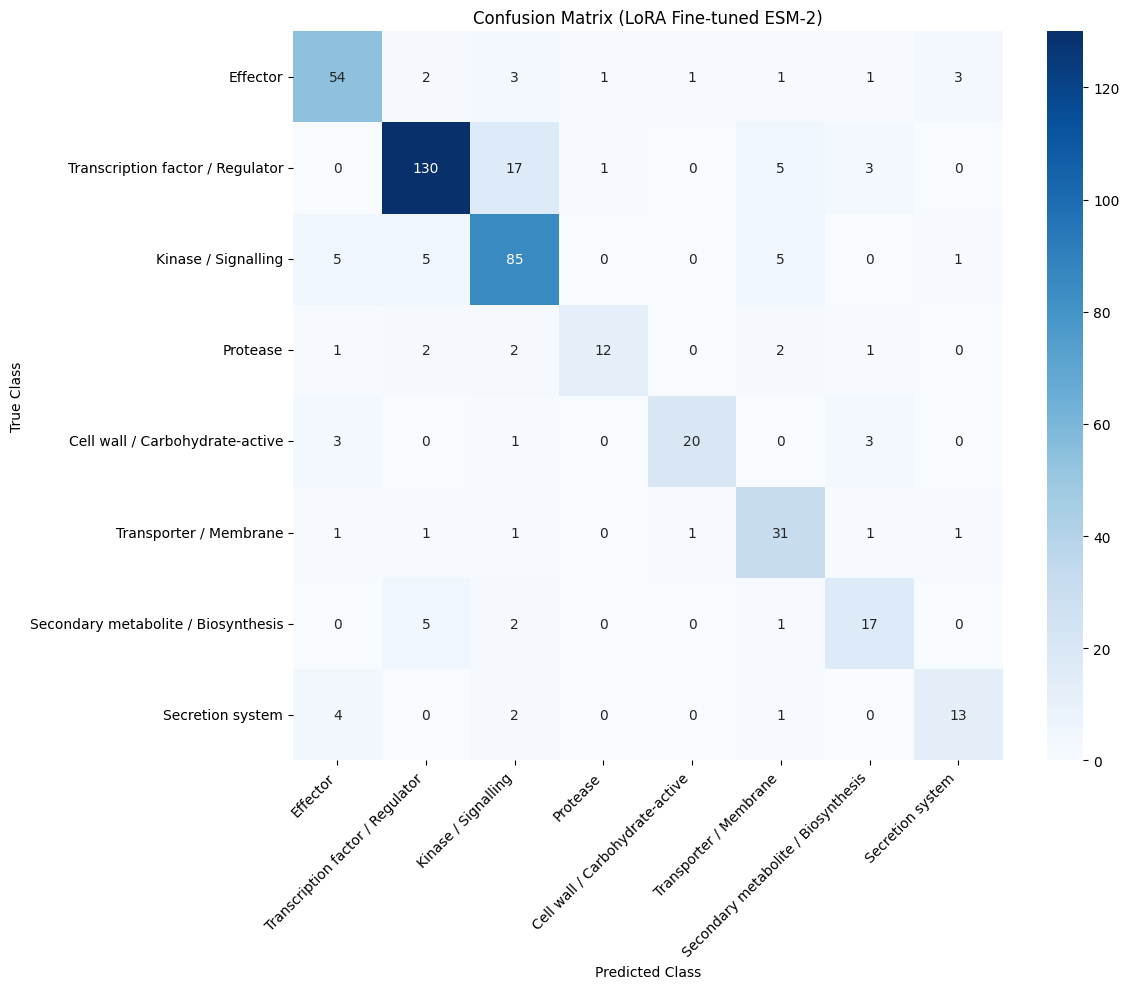

In [19]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(val_labels, val_preds)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)
ax.set_title('Confusion Matrix (LoRA Fine-tuned ESM-2)')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
# Top-2 prediction analysis
top2_preds      = np.argsort(val_logits, axis=1)[:, ::-1][:, :2]
top1_preds      = top2_preds[:, 0]
top2_preds_only = top2_preds[:, 1]

correct_top1         = (top1_preds == val_labels)
correct_top2         = (top2_preds_only == val_labels)
correct_top1_or_top2 = correct_top1 | correct_top2

print(f"Top-1 accuracy:                  {correct_top1.mean()*100:.1f}%")
print(f"Top-2 accuracy (either correct): {correct_top1_or_top2.mean()*100:.1f}%")
print(f"\nOf the {(~correct_top1).sum()} misclassified sequences:")
print(f"  2nd guess correct: {correct_top2[~correct_top1].sum()} ({correct_top2[~correct_top1].mean()*100:.1f}%)")
print(f"  2nd guess wrong:   {(~correct_top2[~correct_top1]).sum()} ({(~correct_top2[~correct_top1]).mean()*100:.1f}%)")
print(f"  Random chance (1 in 7): 14.3%")

# Confusion patterns
from collections import Counter
misclassified_mask = ~correct_top1
true_labels_mis    = val_labels[misclassified_mask]
top1_mis           = top1_preds[misclassified_mask]
top2_mis           = top2_preds_only[misclassified_mask]

confusion_pairs = Counter()
for true, pred1, pred2 in zip(true_labels_mis, top1_mis, top2_mis):
    confusion_pairs[(
        idx_to_class[true],
        idx_to_class[pred1],
        idx_to_class[pred2]
    )] += 1

print("\nMost common confusion patterns (misclassified sequences only):")
print(f"{'1st guess':<45} {'2nd guess':<45} {'2nd = true?':<15} {'Count'}")
print("-" * 115)
for (true, pred1, pred2), count in confusion_pairs.most_common(15):
    second_correct = "✓" if pred2 == true else "✗"
    print(f"{pred1:<45} {pred2:<45} {second_correct:<15} {count}")

Top-1 accuracy:                  80.1%
Top-2 accuracy (either correct): 88.1%

Of the 90 misclassified sequences:
  2nd guess correct: 36 (40.0%)
  2nd guess wrong:   54 (60.0%)
  Random chance (1 in 7): 14.3%

Most common confusion patterns (misclassified sequences only):
1st guess                                     2nd guess                                     2nd = true?     Count
-------------------------------------------------------------------------------------------------------------------
Kinase / Signalling                           Transcription factor / Regulator              ✓               14
Transporter / Membrane                        Kinase / Signalling                           ✓               5
Transcription factor / Regulator              Kinase / Signalling                           ✓               4
Transporter / Membrane                        Kinase / Signalling                           ✗               4
Effector                                      Kinase / 

Truncated sequences: 25 / 452 (5.5%)
Accuracy on truncated:     88.0%
Accuracy on non-truncated: 79.6%


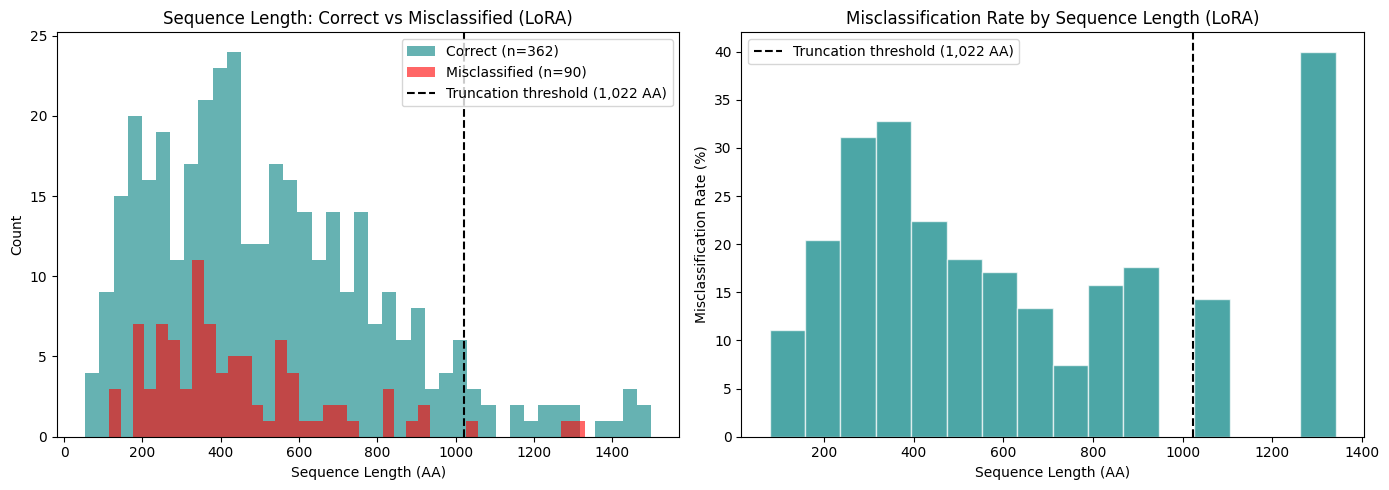

In [21]:
# Truncation analysis
seq_lengths = np.array([len(s) for s in val_data['sequences']])
truncated   = seq_lengths > 1022

print(f"Truncated sequences: {truncated.sum()} / {len(truncated)} ({truncated.mean()*100:.1f}%)")
print(f"Accuracy on truncated:     {correct_top1[truncated].mean()*100:.1f}%")
print(f"Accuracy on non-truncated: {correct_top1[~truncated].mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(seq_lengths[correct_top1],  bins=40, alpha=0.6, color='teal',  label=f'Correct (n={correct_top1.sum()})')
axes[0].hist(seq_lengths[~correct_top1], bins=40, alpha=0.6, color='red',   label=f'Misclassified (n={(~correct_top1).sum()})')
axes[0].axvline(x=1022, color='black', linestyle='--', label='Truncation threshold (1,022 AA)')
axes[0].set_title('Sequence Length: Correct vs Misclassified (LoRA)')
axes[0].set_xlabel('Sequence Length (AA)')
axes[0].set_ylabel('Count')
axes[0].legend()

bin_edges   = np.linspace(0, seq_lengths.max(), 20)
bin_indices = np.digitize(seq_lengths, bin_edges)
bin_error_rates, bin_centres = [], []

for b in range(1, len(bin_edges)):
    mask = bin_indices == b
    if mask.sum() >= 5:
        bin_error_rates.append((~correct_top1[mask]).mean() * 100)
        bin_centres.append((bin_edges[b-1] + bin_edges[b]) / 2)

axes[1].bar(bin_centres, bin_error_rates, width=bin_edges[1]-bin_edges[0],
            color='teal', alpha=0.7, edgecolor='white')
axes[1].axvline(x=1022, color='black', linestyle='--', label='Truncation threshold (1,022 AA)')
axes[1].set_title('Misclassification Rate by Sequence Length (LoRA)')
axes[1].set_xlabel('Sequence Length (AA)')
axes[1].set_ylabel('Misclassification Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6 Model Saving

This section saves the LoRA adapters, classification head weights, and a deployment config JSON to Google Drive and pushes to the GitHub develop branch.

In [24]:
import json

deployment_dir = os.path.join(PROJECT_ROOT, training_config['paths']['deployment_dir'])
os.makedirs(deployment_dir, exist_ok=True)

# Save LoRA adapters and tokenizer
model.esm.save_pretrained(os.path.join(deployment_dir, "lora_adapters"))
tokenizer.save_pretrained(os.path.join(deployment_dir, "tokenizer"))

# Save classification head weights separately
torch.save(
    model.classifier.state_dict(),
    os.path.join(deployment_dir, "classifier_head.pt")
)

print(f"LoRA adapters saved")
print(f"Tokenizer saved")
print(f"Classification head saved")

LoRA adapters saved
Tokenizer saved
Classification head saved


In [25]:
# Save deployment config
deployment_config = {
    "model": {
        "base_model":   model_name,
        "hidden_dim":   model_config['model']['hidden_dim'],
        "num_classes":  model_config['model']['num_classes'],
        "layer_1_dim":  model_config['classification_head']['layer_1_dim'],
        "layer_2_dim":  model_config['classification_head']['layer_2_dim'],
        "dropout_rate": model_config['model']['dropout_rate'],
        "pooling":      model_config['classification_head']['pooling']
    },
    "lora": {
        "rank":           training_config['lora']['rank'],
        "alpha":          training_config['lora']['alpha'],
        "dropout":        training_config['lora']['dropout'],
        "target_modules": training_config['lora']['target_modules'],
        "bias":           training_config['lora']['bias']
    },
    "training": {
        "learning_rate":               training_config['training']['learning_rate'],
        "num_epochs":                  training_config['training']['num_epochs'],
        "batch_size":                  training_config['training']['per_device_train_batch_size'],
        "gradient_accumulation_steps": training_config['training']['gradient_accumulation_steps'],
        "warmup_ratio":                training_config['training']['warmup_ratio'],
        "lr_scheduler_type":           training_config['training']['lr_scheduler_type'],
        "class_weighting":             True
    },
    "label_mapping": train_data['label_mapping'],
    "performance": {
        "frozen_baseline": {
            "accuracy":    0.752,
            "macro_f1":    0.711,
            "weighted_f1": 0.757
        },
        "lora_finetuned": {
            "accuracy":    round(float(val_results['eval_accuracy']), 4),
            "macro_f1":    round(float(val_results['eval_f1_macro']), 4),
            "weighted_f1": round(float(val_results['eval_f1_weighted']), 4)
        }
    },
    "dataset": {
        "source":      "PHI-base",
        "total_seqs":  len(train_data['sequences']) + len(val_data['sequences']) + len(test_data['sequences']),
        "train_seqs":  len(train_data['sequences']),
        "val_seqs":    len(val_data['sequences']),
        "test_seqs":   len(test_data['sequences']),
        "split":       "80/10/10"
    }
}

config_path = os.path.join(deployment_dir, "deployment_config.json")
with open(config_path, 'w') as f:
    json.dump(deployment_config, f, indent=2)

print(f"Deployment config saved to {config_path}")
print(json.dumps(deployment_config, indent=2))

Deployment config saved to /content/drive/MyDrive/esm-phi-effector/data/checkpoints/deployment/deployment_config.json
{
  "model": {
    "base_model": "facebook/esm2_t30_150M_UR50D",
    "hidden_dim": 640,
    "num_classes": 8,
    "layer_1_dim": 256,
    "layer_2_dim": 128,
    "dropout_rate": 0.1,
    "pooling": "mean"
  },
  "lora": {
    "rank": 16,
    "alpha": 32,
    "dropout": 0.1,
    "target_modules": [
      "query",
      "key",
      "value",
      "dense"
    ],
    "bias": "none"
  },
  "training": {
    "learning_rate": 0.0002,
    "num_epochs": 20,
    "batch_size": 8,
    "gradient_accumulation_steps": 2,
    "warmup_ratio": 0.1,
    "lr_scheduler_type": "cosine",
    "class_weighting": true
  },
  "label_mapping": {
    "Effector": 0,
    "Transcription factor / Regulator": 1,
    "Kinase / Signalling": 2,
    "Protease": 3,
    "Cell wall / Carbohydrate-active": 4,
    "Transporter / Membrane": 5,
    "Secondary metabolite / Biosynthesis": 6,
    "Secretion system":

In [26]:
# Close W&B run
wandb.finish()
print("W&B run closed")

baseline/accuracy,▁
baseline/f1_cell_wall_carbohydrate_active,▁
baseline/f1_effector,▁
baseline/f1_kinase_signalling,▁
baseline/f1_protease,▁
baseline/f1_secondary_metabolite_biosynthesis,▁
baseline/f1_secretion_system,▁
baseline/f1_transcription_factor_regulator,▁
baseline/f1_transporter_membrane,▁
baseline/macro_f1,▁
+68,...


W&B run closed
